# Lab 2: Mayo Clinic PBC Trial

## Research Question
### How is age associated with cholesterol level among participants in the Mayo Clinic PBC trial?

## Import packages and load data

In [1]:
import pandas as pd

url = "https://vincentarelbundock.github.io/Rdatasets/csv/survival/pbc.csv"
pbc = pd.read_csv(url)

## Inspecting the Data

In [2]:
pbc.head()

,rownames,id,time,status,trt,age,sex,ascites,hepato,spiders,...,bili,chol,albumin,copper,alk.phos,ast,trig,platelet,protime,stage
0,1,1,400,2,1.0,58.765229,f,1.0,1.0,1.0,...,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,2,4500,0,1.0,56.446270,f,0.0,1.0,1.0,...,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,3,1012,2,1.0,70.072553,m,0.0,0.0,0.0,...,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,4,1925,2,1.0,54.740589,f,0.0,1.0,1.0,...,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,5,1504,1,2.0,38.105407,f,0.0,1.0,1.0,...,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [3]:
pbc.shape

(418, 21)

In [4]:
pbc.columns

Index(['rownames', 'id', 'time', 'status', 'trt', 'age', 'sex', 'ascites',
       'hepato', 'spiders', 'edema', 'bili', 'chol', 'albumin', 'copper',
       'alk.phos', 'ast', 'trig', 'platelet', 'protime', 'stage'],
      dtype='str')

## Data cleanup

In [5]:
pbc[['age', 'chol']].isna().sum()

age       0
chol    134
dtype: int64

In [6]:
analysis_data = pbc[['age', 'chol']].dropna()

In [7]:
analysis_data.shape

(284, 2)

## Analysis

In [8]:
analysis_data.describe()

,age,chol
count,284.000000,284.000000
mean,49.958643,369.510563
std,10.505921,231.944545
min,26.277892,120.000000
25%,42.464750,249.500000
50%,49.794661,309.500000
75%,56.646133,400.000000
max,78.439425,1775.000000


In [9]:
analysis_data.corr()

,age,chol
age,1.00000,-0.15762
chol,-0.15762,1.00000


In [10]:
analysis_data = analysis_data.copy()

analysis_data['age_group'] = pd.cut(
    analysis_data['age'],
    bins=[0, 40, 50, 60, 70, 100],
    labels=['<40', '40-49', '50-59', '60-69', '70+']
)

In [11]:
analysis_data.groupby('age_group', observed=True)['chol'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
age_group,,,
<40,53,392.169811,328.0
40-49,91,398.230769,316.0
50-59,88,351.954545,280.0
60-69,43,342.627907,334.0
70+,9,245.777778,225.0


## Visualisation (scatterplot)

In [12]:
import matplotlib.pyplot as pl

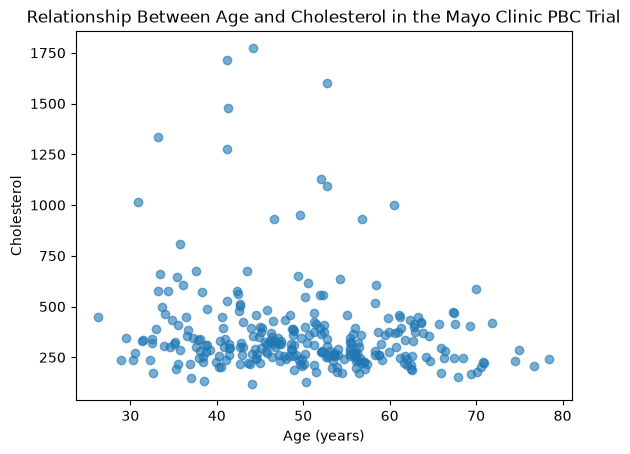

In [13]:
pl.scatter(analysis_data['age'], analysis_data['chol'], alpha=0.6)

pl.xlabel('Age (years)')
pl.ylabel('Cholesterol')
pl.title('Relationship Between Age and Cholesterol in the Mayo Clinic PBC Trial')

pl.show()

## interpretation

### This graph and the correlation coefficent (-0.16) show that there is a weak negative correlation. This suggest that as age increases cholesterol slightly decreases however, the association is not strong. The scatterplot shows that there is variation, including very high value outliers, in cholesterol counts across ages. Showing that age alone doesn't appear to strongely explain cholesterol levels.

## AI Assistance

### I was having trouble producing the plot because of this error "NameError Traceback (most recent call last) Cell In[24], line 1 → 1 plt.scatter(analysis_datal'age'], analysis_datal'chol'l, alpha=0.6) 3 plt.xlabel ('Age (years) ') 4 plt.ylabel('Cholesterol') NameError: name 'plt' is not" and when I pasted the error into openAI it helped me remember that I forgot to import matpoltlib into the notebook. I did have to change the suggestion because it recommend to import matplotlib.pyplot as plt but I had code for the scatterplot written with pl. instead.